
ANOVA for E
                                 sum_sq   df           F    PR(>F)
C(Material)                47928.352033  1.0  127.926424  0.000003
C(StrainRate)                362.120533  1.0    0.966542  0.354338
C(Material):C(StrainRate)     14.963333  1.0    0.039939  0.846587
Residual                    2997.244867  8.0         NaN       NaN

ANOVA for sigma_s
                                 sum_sq   df             F    PR(>F)
C(Material)                7.657888e-12  1.0  2.009718e-14  1.000000
C(StrainRate)              4.851924e+04  1.0  1.273328e+02  0.000029
C(Material):C(StrainRate)  1.409410e+05  1.0  3.698822e+02  0.000001
Residual                   2.286257e+03  6.0           NaN       NaN

ANOVA for sigma_f
                                 sum_sq   df             F    PR(>F)
C(Material)                6.255100e-11  1.0  1.808747e-13  1.000000
C(StrainRate)              5.189139e+04  1.0  1.500509e+02  0.000018
C(Material):C(StrainRate)  1.353362e+05  1.0  3.913429e+02  0.

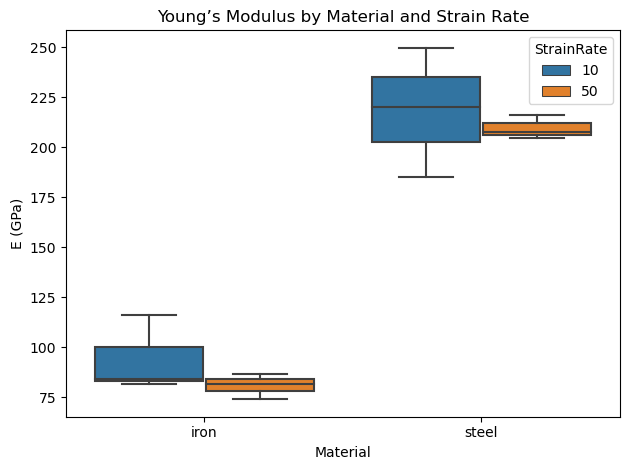

In [1]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

# 数据
data = pd.DataFrame({
    'Material': ['iron']*6 + ['steel']*6,
    'StrainRate': ['10','10','10','50','50','50','10','10','10','50','50','50'],
    'E': [84.18,81.76,116.36,86.70,74.07,81.87,220.26,184.89,249.64,215.98,204.73,207.82],
    'sigma_s': [119.54,185.99,146.10,155.65,154.24,149.21,None,None,None,455.41,461.79,461.49],
    'sigma_f': [142.05,196.74,184.58,200.27,173.72,182.05,None,None,None,480.84,491.42,484.90]
})

# 只分析存在数据的行
for param in ['E','sigma_s','sigma_f']:
    df = data.dropna(subset=[param])
    model = ols(f'{param} ~ C(Material) + C(StrainRate) + C(Material):C(StrainRate)', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f'\nANOVA for {param}')
    print(anova_table)

# 箱线图示例（E）
sns.boxplot(data=data, x='Material', y='E', hue='StrainRate')
plt.title('Young’s Modulus by Material and Strain Rate')
plt.ylabel('E (GPa)')
plt.tight_layout()
plt.show()


                           sum_sq   df           F    PR(>F)
C(Material)          47928.352033  1.0  127.926424  0.000003
C(Rate)                362.120533  1.0    0.966542  0.354338
C(Material):C(Rate)     14.963333  1.0    0.039939  0.846587
Residual              2997.244867  8.0         NaN       NaN
                           sum_sq   df             F    PR(>F)
C(Material)          1.250751e-10  1.0  3.617493e-13  1.000000
C(Rate)              5.189353e+04  1.0  1.500894e+02  0.000018
C(Material):C(Rate)  1.353362e+05  1.0  3.914269e+02  0.000001
Residual             2.074505e+03  6.0           NaN       NaN


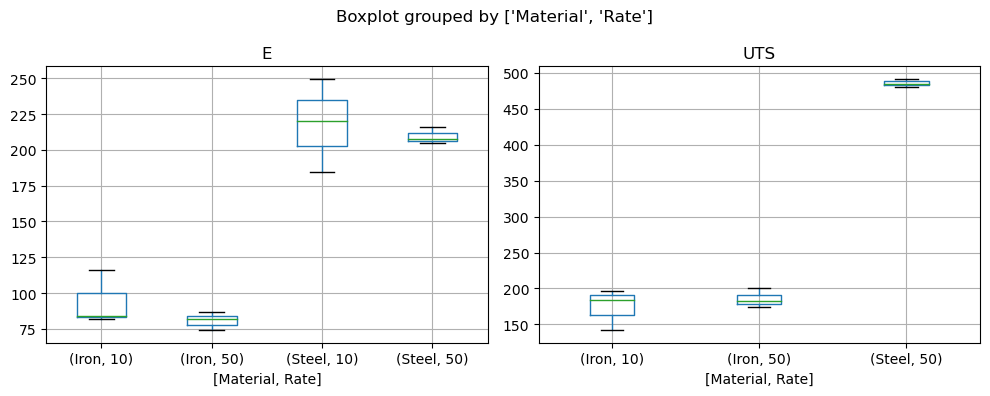

In [2]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt

# 数据整理
data = pd.DataFrame({
    'Material': ['Iron']*6 + ['Steel']*6,
    'Rate': ['10']*3 + ['50']*3 + ['10']*3 + ['50']*3,
    'E': [84.18, 81.76, 116.36, 86.70, 74.07, 81.87,
          220.26, 184.89, 249.64, 215.98, 204.73, 207.82],
    'UTS': [142.05, 196.73, 184.58, 200.27, 173.72, 182.05,
            None, None, None, 480.84, 491.42, 484.90]
})

# E 的两因素 ANOVA
model_E = ols('E ~ C(Material) + C(Rate) + C(Material):C(Rate)', data=data).fit()
anova_E = sm.stats.anova_lm(model_E, typ=2)

# UTS 仅分析有效样本
data_uts = data.dropna(subset=['UTS'])
model_UTS = ols('UTS ~ C(Material) + C(Rate) + C(Material):C(Rate)', data=data_uts).fit()
anova_UTS = sm.stats.anova_lm(model_UTS, typ=2)

print(anova_E)
print(anova_UTS)

# 可视化
fig, axes = plt.subplots(1,2, figsize=(10,4))
data.boxplot(column='E', by=['Material','Rate'], ax=axes[0])
data_uts.boxplot(column='UTS', by=['Material','Rate'], ax=axes[1])
plt.tight_layout()
